In [2]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../../../')

In [ ]:
import glob
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, cross_validate

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin

from tqdm import tqdmd
import pickle

from joblib import Parallel, delayed

import numpy as np

## Load results

Loads all pickle files from the results directory into a nested dict:
```
results[session][area] = {
    '_meta': {...},
    'left_paw':   {'pre': (n_folds,), 'post': (n_folds,)},
    'left_wrist': {'pre': ..., 'post': ...},
    ...
}
```

In [77]:
RESULTS_DIR = Path('/data/equake_results/encoding_decoding/')
ALL_KEYPOINTS = [
    "hip_center",
    "left_ankle",
    "left_elbow",
    "left_foot",
    "left_knee",
    "left_paw",
    "left_shoulder",
    "left_wrist",
    "right_ankle",
    "right_elbow",
    "right_foot",
    "right_knee",
    "right_paw",
    "right_shoulder",
    "right_wrist",
    "shoulder_center",
    "tail_base",
    "tail_middle",
    "tail_tip",
]
pkl_files = sorted(RESULTS_DIR.glob('kin_dec_pre_post_*.pkl'))
print(f'Found {len(pkl_files)} files')

results = {}
for f in pkl_files:
    with open(f, 'rb') as fh:
        data = pickle.load(fh)
    meta    = data['_meta']
    session = meta['session']
    area    = meta['area']
    results.setdefault(session, {})[area] = data

sessions = sorted(results.keys())
areas    = sorted({a for s in results.values() for a in s})
print(f'Sessions : {sessions}')
print(f'Areas    : {areas}')

Found 62 files
Sessions : ['M061_2025_03_04_10_00', 'M061_2025_03_05_14_00', 'M061_2025_03_06_14_00', 'M062_2025_03_20_14_00', 'M062_2025_03_21_14_00', 'M063_2025_03_13_14_00', 'M063_2025_03_14_15_30', 'M078_2025_08_06_15_00', 'M086_2025_12_10_15_00']
Areas    : ['CP', 'MOp', 'SSp', 'VAL']


In [78]:
results['M061_2025_03_04_10_00']['MOp']['hip_center']

{'pre': array([0.30197317, 0.41467942, 0.47032223, 0.44851873, 0.36382901]),
 'post': array([0.30260988, 0.31950013, 0.3992663 , 0.30481093, 0.3467675 ])}

M061_2025_03_04_10_00 | MOp | pre: mean R²=0.464 ± 0.031
M061_2025_03_04_10_00 | MOp | post: mean R²=0.383 ± 0.024
M061_2025_03_04_10_00 | SSp | pre: mean R²=0.206 ± 0.016
M061_2025_03_04_10_00 | SSp | post: mean R²=0.161 ± 0.011
M061_2025_03_04_10_00 | CP | pre: mean R²=0.203 ± 0.011
M061_2025_03_04_10_00 | CP | post: mean R²=0.199 ± 0.006
M061_2025_03_04_10_00 | VAL | pre: mean R²=0.295 ± 0.019
M061_2025_03_04_10_00 | VAL | post: mean R²=0.266 ± 0.013


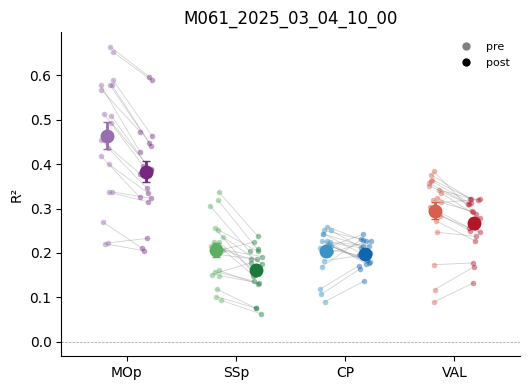

M061_2025_03_05_14_00 | MOp | pre: mean R²=0.399 ± 0.031
M061_2025_03_05_14_00 | MOp | post: mean R²=0.329 ± 0.025
M061_2025_03_05_14_00 | SSp | pre: mean R²=0.226 ± 0.030
M061_2025_03_05_14_00 | SSp | post: mean R²=0.185 ± 0.025
M061_2025_03_05_14_00 | CP | pre: mean R²=0.330 ± 0.029
M061_2025_03_05_14_00 | CP | post: mean R²=0.304 ± 0.022
M061_2025_03_05_14_00 | VAL | pre: mean R²=0.192 ± 0.017
M061_2025_03_05_14_00 | VAL | post: mean R²=0.189 ± 0.014


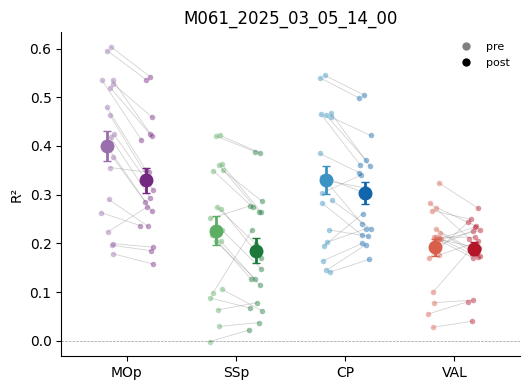

M061_2025_03_06_14_00 | MOp | pre: mean R²=0.378 ± 0.019
M061_2025_03_06_14_00 | MOp | post: mean R²=0.314 ± 0.013
M061_2025_03_06_14_00 | SSp | pre: mean R²=0.318 ± 0.021
M061_2025_03_06_14_00 | SSp | post: mean R²=0.280 ± 0.017
M061_2025_03_06_14_00 | CP | pre: mean R²=0.209 ± 0.022
M061_2025_03_06_14_00 | CP | post: mean R²=0.191 ± 0.018
M061_2025_03_06_14_00 | VAL | pre: mean R²=0.204 ± 0.017
M061_2025_03_06_14_00 | VAL | post: mean R²=0.202 ± 0.017


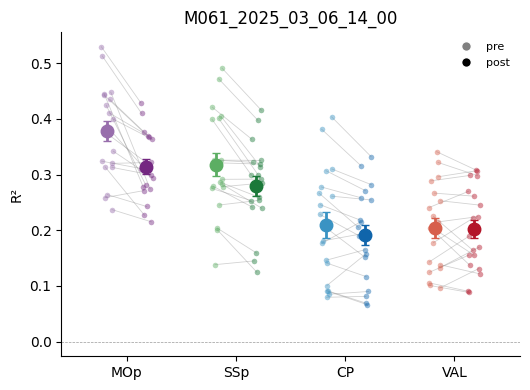

M063_2025_03_13_14_00 | MOp | pre: mean R²=0.380 ± 0.021
M063_2025_03_13_14_00 | MOp | post: mean R²=0.344 ± 0.020
M063_2025_03_13_14_00 | SSp | pre: mean R²=0.294 ± 0.025
M063_2025_03_13_14_00 | SSp | post: mean R²=0.223 ± 0.028
M063_2025_03_13_14_00 | CP | pre: mean R²=0.152 ± 0.007
M063_2025_03_13_14_00 | CP | post: mean R²=0.129 ± 0.009
M063_2025_03_13_14_00 | VAL | pre: mean R²=0.211 ± 0.006
M063_2025_03_13_14_00 | VAL | post: mean R²=0.180 ± 0.009


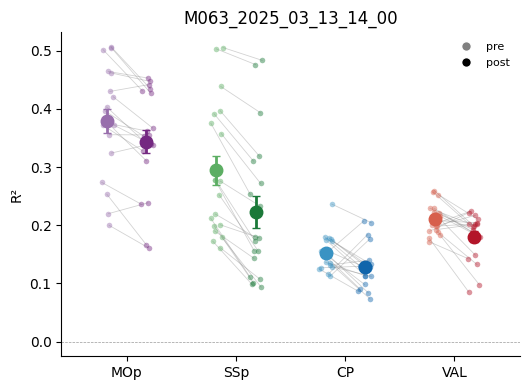

M063_2025_03_14_15_30 | MOp | pre: mean R²=0.414 ± 0.024
M063_2025_03_14_15_30 | MOp | post: mean R²=0.273 ± 0.022
M063_2025_03_14_15_30 | SSp | pre: mean R²=0.338 ± 0.022
M063_2025_03_14_15_30 | SSp | post: mean R²=0.256 ± 0.020
M063_2025_03_14_15_30 | CP | pre: mean R²=0.133 ± 0.008
M063_2025_03_14_15_30 | CP | post: mean R²=0.103 ± 0.008
M063_2025_03_14_15_30 | VAL | pre: mean R²=0.209 ± 0.012
M063_2025_03_14_15_30 | VAL | post: mean R²=0.113 ± 0.007


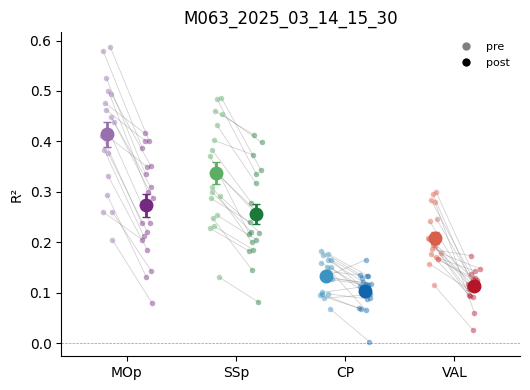

M062_2025_03_20_14_00 | MOp | pre: mean R²=0.295 ± 0.008
M062_2025_03_20_14_00 | MOp | post: mean R²=0.251 ± 0.015
M062_2025_03_20_14_00 | SSp | pre: mean R²=0.342 ± 0.020
M062_2025_03_20_14_00 | SSp | post: mean R²=0.235 ± 0.023
M062_2025_03_20_14_00 | CP | pre: mean R²=0.197 ± 0.013
M062_2025_03_20_14_00 | CP | post: mean R²=0.224 ± 0.011


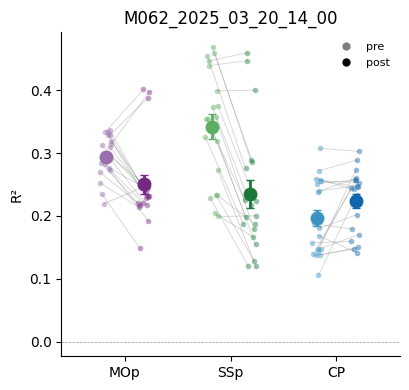

M062_2025_03_21_14_00 | MOp | pre: mean R²=0.376 ± 0.015
M062_2025_03_21_14_00 | MOp | post: mean R²=0.275 ± 0.017
M062_2025_03_21_14_00 | SSp | pre: mean R²=0.396 ± 0.020
M062_2025_03_21_14_00 | SSp | post: mean R²=0.304 ± 0.019
M062_2025_03_21_14_00 | CP | pre: mean R²=0.187 ± 0.016
M062_2025_03_21_14_00 | CP | post: mean R²=0.186 ± 0.012


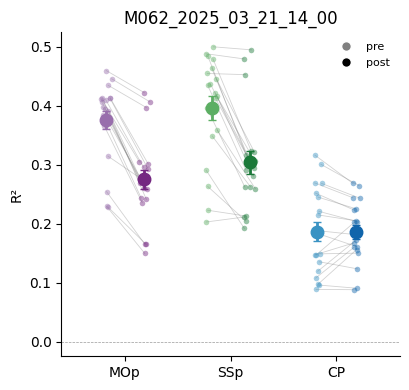

M078_2025_08_06_15_00 | MOp | pre: mean R²=0.242 ± 0.041
M078_2025_08_06_15_00 | MOp | post: mean R²=0.240 ± 0.030
M078_2025_08_06_15_00 | SSp | pre: mean R²=0.162 ± 0.028
M078_2025_08_06_15_00 | SSp | post: mean R²=0.128 ± 0.023
M078_2025_08_06_15_00 | CP | pre: mean R²=0.094 ± 0.016
M078_2025_08_06_15_00 | CP | post: mean R²=0.064 ± 0.013
M078_2025_08_06_15_00 | VAL | pre: mean R²=0.052 ± 0.018
M078_2025_08_06_15_00 | VAL | post: mean R²=0.066 ± 0.015


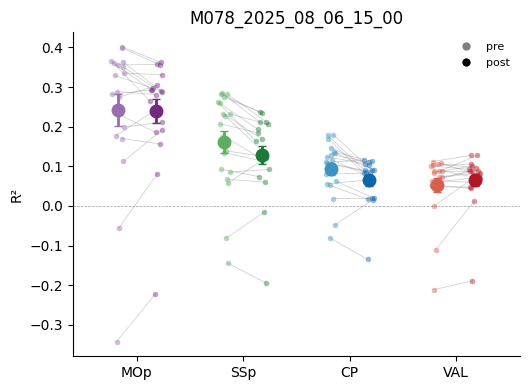

In [79]:

SHOW_SESSIONS = [
    "M061_2025_03_04_10_00",
    "M061_2025_03_05_14_00",
    "M061_2025_03_06_14_00",
    "M063_2025_03_13_14_00",
    "M063_2025_03_14_15_30",
    "M062_2025_03_20_14_00",
    "M062_2025_03_21_14_00",
    "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]

sessions = SHOW_SESSIONS

AREA_ORDER = ['MOp', 'SSp', 'CP', 'VAL']
OFFSET     = 0.18   # half-distance between pre/post sub-positions
JITTER     = 0.06
KP_ALPHA   = 0.35

# dark = post, light = pre
AREA_COLORS = {
    area: {
        'post': getattr(colors, area),
        'pre':  getattr(colors, f'{area}_light'),
    }
    for area in AREA_ORDER
}

rng = np.random.default_rng(0)

for sess in SHOW_SESSIONS:
    if sess not in results:
        print(f'Session not found: {sess}')
        continue
    sess_areas = [a for a in AREA_ORDER if a in results[sess]]
    if not sess_areas:
        continue

    fig, ax = plt.subplots(figsize=(len(sess_areas) * 1.2 + 0.6, 4))

    kp_sets = [
        set(k for k in results[sess][a] if k != '_meta'
            and 'pre' in results[sess][a][k] and 'post' in results[sess][a][k])
        for a in sess_areas
    ]
    common_kps = sorted(set.intersection(*kp_sets))

    for ai, area in enumerate(sess_areas):
        x_pre  = ai - OFFSET
        x_post = ai + OFFSET
        col_pre  = AREA_COLORS[area]['pre']
        col_post = AREA_COLORS[area]['post']

        pre_vals  = np.array([results[sess][area][kp]['pre'].mean()  for kp in common_kps])
        post_vals = np.array([results[sess][area][kp]['post'].mean() for kp in common_kps])

        for v_pre, v_post in zip(pre_vals, post_vals):
            jx = rng.uniform(-JITTER, JITTER)
            ax.plot([x_pre + jx, x_post + jx], [v_pre, v_post],
                    color='grey', lw=0.6, alpha=KP_ALPHA, zorder=1)
            ax.scatter(x_pre  + jx, v_pre,  color=col_pre,  s=16, alpha=KP_ALPHA + 0.1,
                       zorder=2, linewidths=0)
            ax.scatter(x_post + jx, v_post, color=col_post, s=16, alpha=KP_ALPHA + 0.1,
                       zorder=2, linewidths=0)

        for x, vals, col, win in [(x_pre, pre_vals, col_pre, 'pre'),
                                   (x_post, post_vals, col_post, 'post')]:
            m, se = vals.mean(), vals.std() / np.sqrt(len(vals))
            ax.errorbar(x, m, yerr=se, fmt='o', color=col,
                        markersize=9, capsize=3, lw=2, zorder=5)
            print(f'{sess} | {area} | {win}: mean R²={m:.3f} ± {se:.3f}')

    ax.set_xticks(range(len(sess_areas)))
    ax.set_xticklabels(sess_areas)
    ax.set_ylabel('R²')
    ax.set_title(sess)
    ax.set_xlim(-0.6, len(sess_areas) - 0.4)
    ax.axhline(0, color='k', lw=0.5, ls='--', alpha=0.4)

    from matplotlib.lines import Line2D
    ax.legend(
        handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
                        markersize=7, label='pre'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
                        markersize=7, label='post')],
        frameon=False, fontsize=8, loc='upper right'
    )

    sns.despine(ax=ax)
    fig.tight_layout()
    plt.show()


MOp | pre: mean R²=0.368 ± 0.023  (n=8 sessions)
MOp | post: mean R²=0.301 ± 0.016  (n=8 sessions)
SSp | pre: mean R²=0.285 ± 0.026  (n=8 sessions)
SSp | post: mean R²=0.222 ± 0.020  (n=8 sessions)
CP | pre: mean R²=0.188 ± 0.023  (n=8 sessions)
CP | post: mean R²=0.175 ± 0.025  (n=8 sessions)
VAL | pre: mean R²=0.194 ± 0.029  (n=6 sessions)
VAL | post: mean R²=0.170 ± 0.026  (n=6 sessions)


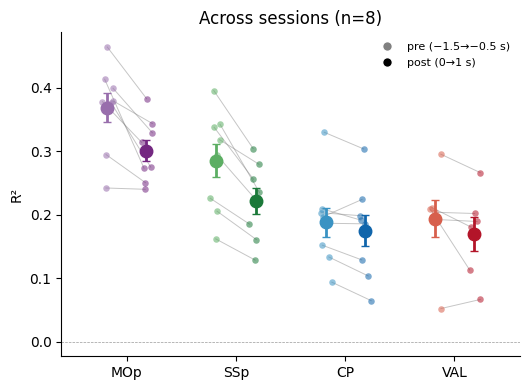

In [80]:

GRAND_SESSIONS = sessions   # sessions to include
GRAND_KPS      = None       # None = all common keypoints, or e.g. ['left_paw', 'left_wrist']
GRAND_AREAS    = ['MOp', 'SSp', 'CP', 'VAL']
OFFSET         = 0.18
JITTER         = 0.06
KP_ALPHA       = 0.45

AREA_COLORS = {
    area: {'post': getattr(colors, area), 'pre': getattr(colors, f'{area}_light')}
    for area in GRAND_AREAS
}

# build per-session mean R² (averaged across keypoints) for each area × window
sess_vals = {}   # sess → area → window → scalar
for sess in GRAND_SESSIONS:
    if sess not in results:
        continue
    row = {}
    for area in GRAND_AREAS:
        if area not in results[sess]:
            continue
        d = results[sess][area]
        kps = [k for k in d if k != '_meta'
               and 'pre' in d[k] and 'post' in d[k]]
        if GRAND_KPS is not None:
            kps = [k for k in kps if k in GRAND_KPS]
        if not kps:
            continue
        row[area] = {
            win: np.mean([d[kp][win].mean() for kp in kps])
            for win in ('pre', 'post')
        }
    if row:
        sess_vals[sess] = row

plot_areas = [a for a in GRAND_AREAS if any(a in v for v in sess_vals.values())]

fig, ax = plt.subplots(figsize=(len(plot_areas) * 1.2 + 0.6, 4))
rng = np.random.default_rng(1)

for ai, area in enumerate(plot_areas):
    x_pre, x_post = ai - OFFSET, ai + OFFSET
    col_pre  = AREA_COLORS[area]['pre']
    col_post = AREA_COLORS[area]['post']

    pre_vals  = np.array([sess_vals[s][area]['pre']  for s in sess_vals if area in sess_vals[s]])
    post_vals = np.array([sess_vals[s][area]['post'] for s in sess_vals if area in sess_vals[s]])

    for v_pre, v_post in zip(pre_vals, post_vals):
        jx = rng.uniform(-JITTER, JITTER)
        ax.plot([x_pre + jx, x_post + jx], [v_pre, v_post],
                color='grey', lw=0.7, alpha=KP_ALPHA, zorder=1)
        ax.scatter(x_pre  + jx, v_pre,  color=col_pre,  s=22, alpha=KP_ALPHA + 0.1,
                   zorder=2, linewidths=0)
        ax.scatter(x_post + jx, v_post, color=col_post, s=22, alpha=KP_ALPHA + 0.1,
                   zorder=2, linewidths=0)

    for x, vals, col, win in [(x_pre, pre_vals, col_pre, 'pre'),
                               (x_post, post_vals, col_post, 'post')]:
        m, se = vals.mean(), vals.std() / np.sqrt(len(vals))
        ax.errorbar(x, m, yerr=se, fmt='o', color=col,
                    markersize=9, capsize=3, lw=2, zorder=5)
        print(f'{area} | {win}: mean R²={m:.3f} ± {se:.3f}  (n={len(vals)} sessions)')

ax.set_xticks(range(len(plot_areas)))
ax.set_xticklabels(plot_areas)
ax.set_ylabel('R²')
ax.set_title(f'Across sessions (n={len(sess_vals)})')
ax.set_xlim(-0.6, len(plot_areas) - 0.4)
ax.axhline(0, color='k', lw=0.5, ls='--', alpha=0.4)

from matplotlib.lines import Line2D
ax.legend(
    handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
                    markersize=7, label='pre (−1.5→−0.5 s)'),
             Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
                    markersize=7, label='post (0→1 s)')],
    frameon=False, fontsize=8, loc='upper right'
)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


MOp | M061: mean z=-4.92  min=-24.31  max=0.11
MOp | M061: mean z=-2.05  min=-4.94  max=0.74
MOp | M061: mean z=-2.40  min=-8.91  max=0.58
MOp | M063: mean z=-0.65  min=-3.35  max=0.36
MOp | M063: mean z=-3.40  min=-6.31  max=-1.03
MOp | M062: mean z=-2.55  min=-8.02  max=3.70
MOp | M062: mean z=-3.92  min=-7.75  max=-1.09
SSp | M061: mean z=-0.89  min=-7.90  max=4.02
SSp | M061: mean z=-2.19  min=-7.43  max=8.73
SSp | M061: mean z=-4.30  min=-23.40  max=-0.29
SSp | M063: mean z=-0.96  min=-2.58  max=-0.17
SSp | M063: mean z=-2.75  min=-10.47  max=-0.88
SSp | M062: mean z=-3.83  min=-10.04  max=0.70
SSp | M062: mean z=-3.23  min=-6.37  max=0.13
CP | M061: mean z=-0.27  min=-1.75  max=4.07
CP | M061: mean z=-1.02  min=-3.86  max=2.07
CP | M061: mean z=-0.39  min=-1.50  max=1.69
CP | M063: mean z=-0.12  min=-0.95  max=1.31
CP | M063: mean z=-0.85  min=-2.95  max=0.64
CP | M062: mean z=2.05  min=-1.31  max=10.57
CP | M062: mean z=0.30  min=-0.60  max=2.85
VAL | M061: mean z=-1.28  min=-3.

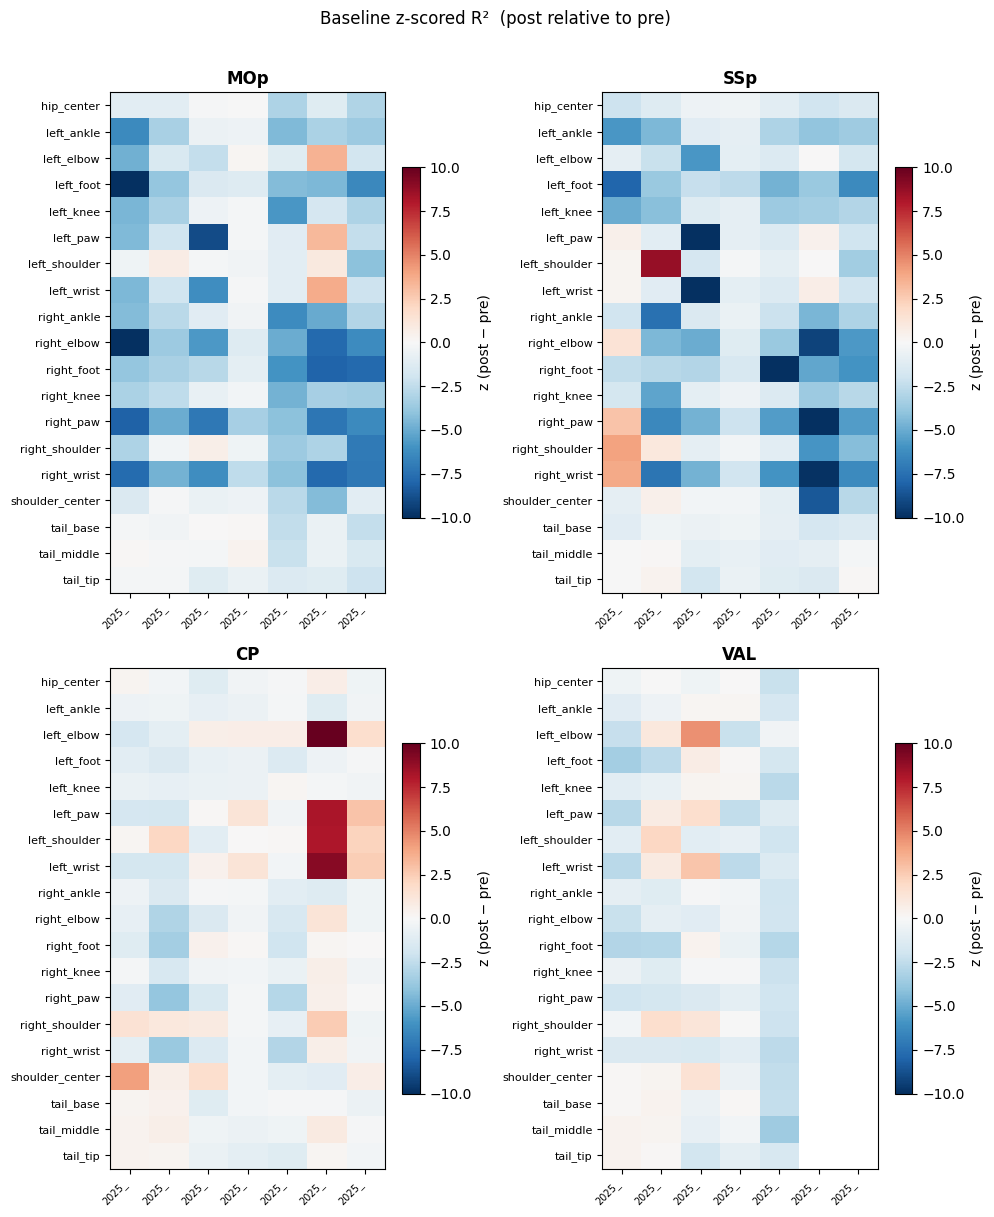

In [8]:

HM_SESSIONS = sessions
HM_AREAS    = ['MOp', 'SSp', 'CP', 'VAL']

def baseline_zscore(pre_folds, post_folds):
    return (post_folds.mean() - pre_folds.mean()) / (pre_folds.std() + 1e-8)

fig, axes = plt.subplots(2, 2, figsize=(10, 12))
axes = axes.flatten()

for ax, area in zip(axes, HM_AREAS):
    all_kps = sorted({
        kp for sess in HM_SESSIONS
        if sess in results and area in results[sess]
        for kp in results[sess][area]
        if kp != '_meta' and 'pre' in results[sess][area][kp] and 'post' in results[sess][area][kp]
    })

    mat = np.full((len(all_kps), len(HM_SESSIONS)), np.nan)
    for si, sess in enumerate(HM_SESSIONS):
        if sess not in results or area not in results[sess]:
            continue
        for ki, kp in enumerate(all_kps):
            d = results[sess][area]
            if kp not in d:
                continue
            mat[ki, si] = baseline_zscore(d[kp]['pre'], d[kp]['post'])

    vmax = np.nanmax(np.abs(mat))
    im = ax.imshow(mat, aspect='auto', cmap='RdBu_r',
                   vmin=-10, vmax=10, interpolation='nearest')

    ax.set_xticks(range(len(HM_SESSIONS)))
    ax.set_xticklabels([s[5:10] for s in HM_SESSIONS], rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(len(all_kps)))
    ax.set_yticklabels(all_kps, fontsize=8)
    ax.set_title(area, fontweight='bold')

    plt.colorbar(im, ax=ax, label='z (post − pre)', shrink=0.7)

    for si, sess in enumerate(HM_SESSIONS):
        col = mat[:, si]
        valid = col[~np.isnan(col)]
        if len(valid):
            print(f'{area} | {sess[:4]}: mean z={valid.mean():.2f}  min={valid.min():.2f}  max={valid.max():.2f}')

fig.suptitle('Baseline z-scored R²  (post relative to pre)', y=1.01)
fig.tight_layout()
plt.show()


In [9]:

SHOW_SESSIONS = [
    "M061_2025_03_04_10_00",
    "M061_2025_03_05_14_00",
    "M061_2025_03_06_14_00",
    "M063_2025_03_13_14_00",
    "M063_2025_03_14_15_30",
    "M062_2025_03_20_14_00",
    "M062_2025_03_21_14_00",
    "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]

sessions = SHOW_SESSIONS

M061_2025_03_04_10_00 | MOp: mean z=-0.08 ± 0.01  (n=19 kps)
M061_2025_03_04_10_00 | SSp: mean z=-0.03 ± 0.01  (n=19 kps)
M061_2025_03_04_10_00 | CP: mean z=-0.00 ± 0.01  (n=19 kps)
M061_2025_03_04_10_00 | VAL: mean z=-0.03 ± 0.01  (n=19 kps)


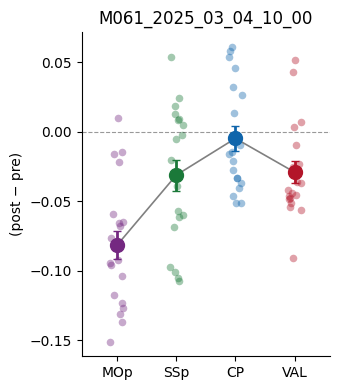

M061_2025_03_05_14_00 | MOp: mean z=-0.07 ± 0.01  (n=19 kps)
M061_2025_03_05_14_00 | SSp: mean z=-0.04 ± 0.01  (n=19 kps)
M061_2025_03_05_14_00 | CP: mean z=-0.03 ± 0.01  (n=19 kps)
M061_2025_03_05_14_00 | VAL: mean z=-0.00 ± 0.01  (n=19 kps)


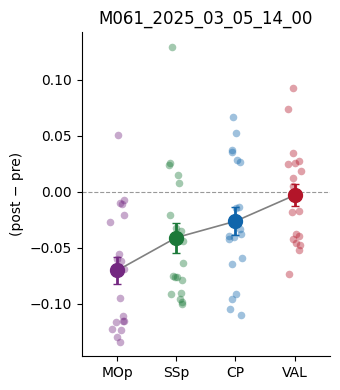

M061_2025_03_06_14_00 | MOp: mean z=-0.06 ± 0.01  (n=19 kps)
M061_2025_03_06_14_00 | SSp: mean z=-0.06 ± 0.01  (n=19 kps)
M061_2025_03_06_14_00 | CP: mean z=-0.02 ± 0.01  (n=19 kps)
M061_2025_03_06_14_00 | VAL: mean z=-0.00 ± 0.01  (n=19 kps)


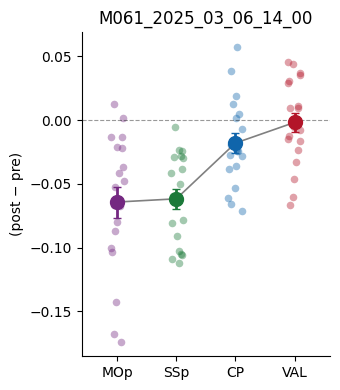

M063_2025_03_13_14_00 | MOp: mean z=-0.04 ± 0.01  (n=19 kps)
M063_2025_03_13_14_00 | SSp: mean z=-0.07 ± 0.01  (n=19 kps)
M063_2025_03_13_14_00 | CP: mean z=-0.02 ± 0.01  (n=19 kps)
M063_2025_03_13_14_00 | VAL: mean z=-0.03 ± 0.01  (n=19 kps)


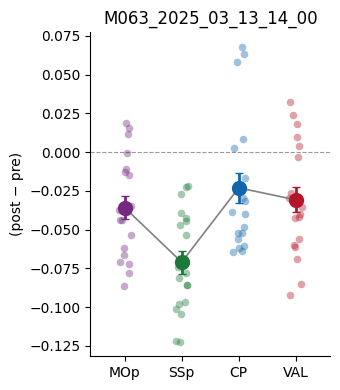

M062_2025_03_20_14_00 | MOp: mean z=-0.04 ± 0.01  (n=19 kps)
M062_2025_03_20_14_00 | SSp: mean z=-0.11 ± 0.02  (n=19 kps)
M062_2025_03_20_14_00 | CP: mean z=0.03 ± 0.01  (n=19 kps)


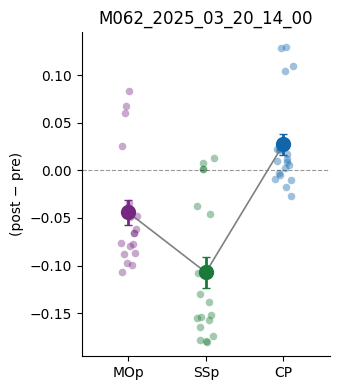

M062_2025_03_21_14_00 | MOp: mean z=-0.10 ± 0.01  (n=19 kps)
M062_2025_03_21_14_00 | SSp: mean z=-0.11 ± 0.01  (n=19 kps)
M062_2025_03_21_14_00 | CP: mean z=-0.00 ± 0.01  (n=19 kps)


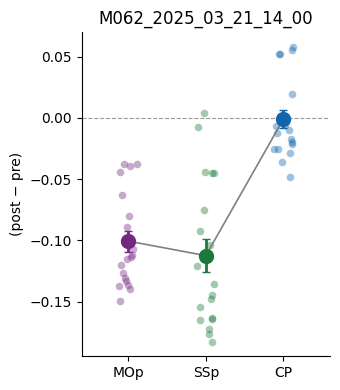

M078_2025_08_06_15_00 | MOp: mean z=-0.04 ± 0.01  (n=19 kps)
M078_2025_08_06_15_00 | SSp: mean z=-0.05 ± 0.01  (n=19 kps)
M078_2025_08_06_15_00 | CP: mean z=-0.03 ± 0.01  (n=19 kps)
M078_2025_08_06_15_00 | VAL: mean z=0.01 ± 0.01  (n=19 kps)


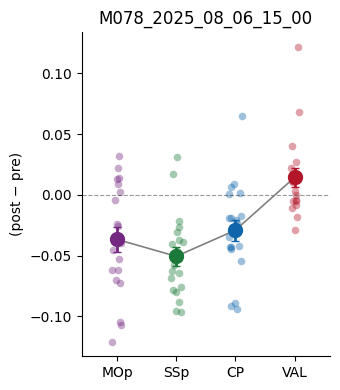

In [38]:

SHOW_SESSIONS = sessions
NORM_AREAS    = ['MOp', 'SSp', 'CP', 'VAL']
JITTER        = 0.12
KP_ALPHA      = 0.4
DOT_SIZE      = 30

AREA_COLORS = {a: getattr(colors, a) for a in NORM_AREAS}

def baseline_zscore(pre_folds, post_folds):
    return (post_folds.mean() - pre_folds.mean()) #/ (pre_folds.std() + 1e-8)

rng = np.random.default_rng(0)

for sess in SHOW_SESSIONS:
    if sess not in results:
        print(f'Session not found: {sess}')
        continue

    sess_areas = [a for a in NORM_AREAS if a in results[sess]]
    if not sess_areas:
        continue

    fig, ax = plt.subplots(figsize=(3.5, 4))

    means = []
    xs_for_line = []

    for ai, area in enumerate(sess_areas):
        d = results[sess][area]
        kps = [k for k in d if k != '_meta' and 'pre' in d[k] and 'post' in d[k]]
        if not kps:
            continue

        zvals = np.array([baseline_zscore(d[kp]['pre'], d[kp]['post']) for kp in kps])

        # individual keypoint dots
        jx = rng.uniform(-JITTER, JITTER, size=len(zvals))
        ax.scatter(ai + jx, zvals, color=AREA_COLORS[area], s=DOT_SIZE,
                   alpha=KP_ALPHA, linewidths=0, zorder=2)

        # mean ± SEM
        m, se = zvals.mean(), zvals.std() / np.sqrt(len(zvals))
        ax.errorbar(ai, m, yerr=se, fmt='o', color=AREA_COLORS[area],
                    markersize=10, capsize=3, lw=2, zorder=4)
        means.append(m)
        xs_for_line.append(ai)

        print(f'{sess} | {area}: mean z={m:.2f} ± {se:.2f}  (n={len(zvals)} kps)')

    # line connecting means
    ax.plot(xs_for_line, means, color='grey', lw=1.2, zorder=3)

    ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
    ax.set_xticks(range(len(sess_areas)))
    ax.set_xticklabels(sess_areas)
    ax.set_ylabel('(post − pre)')
    ax.set_title(sess)
    ax.set_xlim(-0.6, len(sess_areas) - 0.4)
    sns.despine(ax=ax)
    fig.tight_layout()
    plt.show()


In [32]:

SHOW_SESSIONS = [
    "M061_2025_03_04_10_00",
    "M061_2025_03_05_14_00",
    "M061_2025_03_06_14_00",
    "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    "M062_2025_03_20_14_00",
    "M062_2025_03_21_14_00",
    "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]

sessions = SHOW_SESSIONS

MOp: mean z=-0.06 ± 0.02  (n=7 sessions)
SSp: mean z=-0.07 ± 0.03  (n=7 sessions)
CP: mean z=-0.01 ± 0.02  (n=7 sessions)
VAL: mean z=-0.01 ± 0.02  (n=5 sessions)


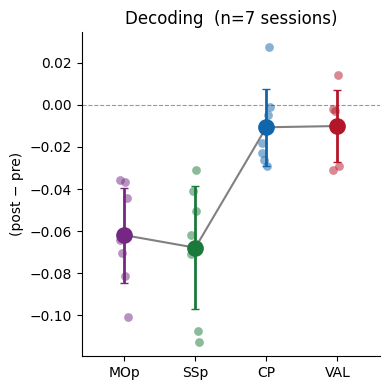

In [48]:

AGG_SESSIONS = sessions
AGG_AREAS    = ['MOp', 'SSp', 'CP', 'VAL']
JITTER       = 0.06
KP_ALPHA     = 0.5
DOT_SIZE     = 40

AREA_COLORS = {a: getattr(colors, a) for a in AGG_AREAS}

def baseline_zscore(pre_folds, post_folds):
    return (post_folds.mean() - pre_folds.mean()) # (pre_folds.std() + 1e-8)

# per-session mean z across keypoints, for each area
sess_area_z = {}   # sess → area → scalar
for sess in AGG_SESSIONS:
    if sess not in results:
        continue
    row = {}
    for area in AGG_AREAS:
        if area not in results[sess]:
            continue
        d = results[sess][area]
        kps = [k for k in d if k != '_meta' and 'pre' in d[k] and 'post' in d[k]]
        if not kps:
            continue
        row[area] = np.mean([baseline_zscore(d[kp]['pre'], d[kp]['post']) for kp in kps])
    if row:
        sess_area_z[sess] = row

fig, ax = plt.subplots(figsize=(4, 4))
rng = np.random.default_rng(0)

# session lines
for sess, row in sess_area_z.items():
    xs = [AGG_AREAS.index(a) for a in AGG_AREAS if a in row]
    ys = [row[a] for a in AGG_AREAS if a in row]
    jx = rng.uniform(-JITTER, JITTER)
    # ax.plot([x + jx for x in xs], ys, color='grey', lw=0.8, alpha=0.4, zorder=1)
    for x, y, area in zip(xs, ys, [a for a in AGG_AREAS if a in row]):
        ax.scatter(x + jx, y, color=AREA_COLORS[area], s=DOT_SIZE,
                   alpha=KP_ALPHA, linewidths=0, zorder=2)

# mean ± SEM per area + connecting line
means, xs_line = [], []
for ai, area in enumerate(AGG_AREAS):
    vals = np.array([sess_area_z[s][area] for s in sess_area_z if area in sess_area_z[s]])
    if not len(vals):
        continue
    m, se = vals.mean(), vals.std() #/ np.sqrt(len(vals))
    ax.errorbar(ai, m, yerr=se, fmt='o', color=AREA_COLORS[area],
                markersize=11, capsize=3, lw=2, zorder=5)
    means.append(m)
    xs_line.append(ai)
    print(f'{area}: mean z={m:.2f} ± {se:.2f}  (n={len(vals)} sessions)')

ax.plot(xs_line, means, color='grey', lw=1.5, zorder=4)

ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
ax.set_xticks(range(len(AGG_AREAS)))
ax.set_xticklabels(AGG_AREAS)
ax.set_ylabel('(post − pre)')
ax.set_title(f'Decoding  (n={len(sess_area_z)} sessions)')
ax.set_xlim(-0.6, len(AGG_AREAS) - 0.4)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


/tmp/ipykernel_1787433/1388989977.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sess_cmap  = plt.cm.get_cmap('tab10', n_sessions)


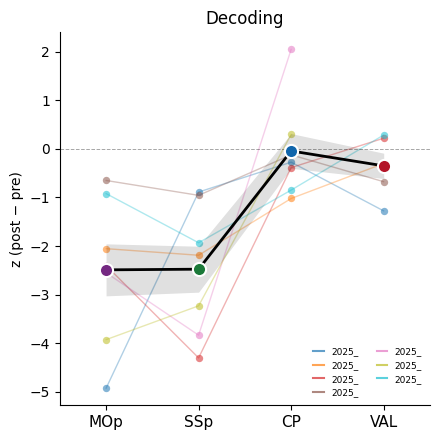

MOp: mean z=-2.49 ± 0.54  (n=7)
SSp: mean z=-2.47 ± 0.47  (n=7)
CP: mean z=-0.04 ± 0.36  (n=7)
VAL: mean z=-0.35 ± 0.26  (n=5)


In [39]:

AGG_SESSIONS = sessions
AGG_AREAS    = ['MOp', 'SSp', 'CP', 'VAL']

AREA_COLORS = {a: getattr(colors, a) for a in AGG_AREAS}

def baseline_zscore(pre_folds, post_folds):
    return (post_folds.mean() - pre_folds.mean()) / (pre_folds.std() + 1e-8)

# per-session mean z across keypoints
sess_area_z = {}
for sess in AGG_SESSIONS:
    if sess not in results:
        continue
    row = {}
    for area in AGG_AREAS:
        if area not in results[sess]:
            continue
        d = results[sess][area]
        kps = [k for k in d if k != '_meta' and 'pre' in d[k] and 'post' in d[k]]
        if kps:
            row[area] = np.mean([baseline_zscore(d[kp]['pre'], d[kp]['post']) for kp in kps])
    if row:
        sess_area_z[sess] = row

sess_list  = list(sess_area_z.keys())
n_sessions = len(sess_list)
sess_cmap  = plt.cm.get_cmap('tab10', n_sessions)
sess_colors = {s: sess_cmap(i) for i, s in enumerate(sess_list)}

fig, ax = plt.subplots(figsize=(4.5, 4.5))

# --- session lines (colored per session, behind everything) ---
for sess, row in sess_area_z.items():
    xs = [AGG_AREAS.index(a) for a in AGG_AREAS if a in row]
    ys = [row[a] for a in AGG_AREAS if a in row]
    ax.plot(xs, ys, color=sess_colors[sess], lw=1.0, alpha=0.35, zorder=1, solid_capstyle='round')
    for x, y in zip(xs, ys):
        ax.scatter(x, y, color=sess_colors[sess], s=28, alpha=0.55, linewidths=0, zorder=2)

# --- SEM ribbon + mean line ---
mean_arr = np.full((len(AGG_AREAS),), np.nan)
sem_arr  = np.full((len(AGG_AREAS),), np.nan)
for ai, area in enumerate(AGG_AREAS):
    vals = np.array([sess_area_z[s][area] for s in sess_list if area in sess_area_z[s]])
    if len(vals):
        mean_arr[ai] = vals.mean()
        sem_arr[ai]  = vals.std() / np.sqrt(len(vals))

valid = ~np.isnan(mean_arr)
xs_v  = np.where(valid)[0]
ax.fill_between(xs_v, mean_arr[valid] - sem_arr[valid],
                       mean_arr[valid] + sem_arr[valid],
                color='k', alpha=0.12, zorder=3, linewidth=0)
ax.plot(xs_v, mean_arr[valid], color='k', lw=2.0, zorder=4, solid_capstyle='round')

# --- area mean dots on top ---
for ai, area in enumerate(AGG_AREAS):
    if not np.isnan(mean_arr[ai]):
        ax.scatter(ai, mean_arr[ai], color=AREA_COLORS[area], s=90,
                   zorder=5, linewidths=1.5, edgecolors='white')

# --- zero reference ---
ax.axhline(0, color='k', lw=0.7, ls='--', alpha=0.35)

# --- legend: sessions ---
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=sess_colors[s], lw=1.5, alpha=0.7,
                  label=s[5:10]) for s in sess_list]
ax.legend(handles=handles, frameon=False, fontsize=6.5,
          loc='lower right', ncol=2, handlelength=1.2)

ax.set_xticks(range(len(AGG_AREAS)))
ax.set_xticklabels(AGG_AREAS, fontsize=11)
ax.set_ylabel('z (post − pre)', fontsize=10)
ax.set_title('Decoding', fontsize=12)
ax.set_xlim(-0.5, len(AGG_AREAS) - 0.5)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

for area in AGG_AREAS:
    vals = np.array([sess_area_z[s][area] for s in sess_list if area in sess_area_z[s]])
    if len(vals):
        print(f'{area}: mean z={vals.mean():.2f} ± {vals.std()/np.sqrt(len(vals)):.2f}  (n={len(vals)})')


M061_2025_03_04_10_00 | MOp | left forelimb: n=4  mean=-3.59
M061_2025_03_04_10_00 | MOp | right forelimb: n=4  mean=-3.87
M061_2025_03_04_10_00 | MOp | left hindlimb: n=3  mean=-6.02
M061_2025_03_04_10_00 | MOp | right hindlimb: n=3  mean=-3.96
M061_2025_03_04_10_00 | MOp | axial: n=5  mean=-0.73
M061_2025_03_04_10_00 | SSp | left forelimb: n=4  mean=0.36
M061_2025_03_04_10_00 | SSp | right forelimb: n=4  mean=2.42
M061_2025_03_04_10_00 | SSp | left hindlimb: n=3  mean=-5.24
M061_2025_03_04_10_00 | SSp | right hindlimb: n=3  mean=-3.41
M061_2025_03_04_10_00 | SSp | axial: n=5  mean=-2.02
M061_2025_03_04_10_00 | CP | left forelimb: n=4  mean=-1.39
M061_2025_03_04_10_00 | CP | right forelimb: n=4  mean=-0.29
M061_2025_03_04_10_00 | CP | left hindlimb: n=3  mean=-0.89
M061_2025_03_04_10_00 | CP | right hindlimb: n=3  mean=-0.42
M061_2025_03_04_10_00 | CP | axial: n=5  mean=1.11
M061_2025_03_04_10_00 | VAL | left forelimb: n=4  mean=-2.24
M061_2025_03_04_10_00 | VAL | right forelimb: n=4 

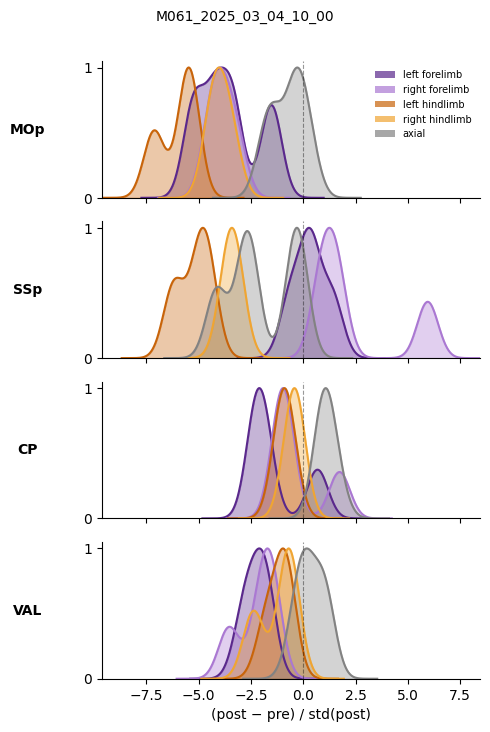

M061_2025_03_05_14_00 | MOp | left forelimb: n=4  mean=-1.30
M061_2025_03_05_14_00 | MOp | right forelimb: n=4  mean=-2.17
M061_2025_03_05_14_00 | MOp | left hindlimb: n=3  mean=-3.50
M061_2025_03_05_14_00 | MOp | right hindlimb: n=3  mean=-3.76
M061_2025_03_05_14_00 | MOp | axial: n=5  mean=-0.52
M061_2025_03_05_14_00 | SSp | left forelimb: n=4  mean=0.54
M061_2025_03_05_14_00 | SSp | right forelimb: n=4  mean=-1.74
M061_2025_03_05_14_00 | SSp | left hindlimb: n=3  mean=-1.42
M061_2025_03_05_14_00 | SSp | right hindlimb: n=3  mean=-3.46
M061_2025_03_05_14_00 | SSp | axial: n=5  mean=0.09
M061_2025_03_05_14_00 | CP | left forelimb: n=4  mean=-0.10
M061_2025_03_05_14_00 | CP | right forelimb: n=4  mean=-1.80
M061_2025_03_05_14_00 | CP | left hindlimb: n=3  mean=-0.60
M061_2025_03_05_14_00 | CP | right hindlimb: n=3  mean=-1.46
M061_2025_03_05_14_00 | CP | axial: n=5  mean=0.48
M061_2025_03_05_14_00 | VAL | left forelimb: n=4  mean=1.82
M061_2025_03_05_14_00 | VAL | right forelimb: n=4  

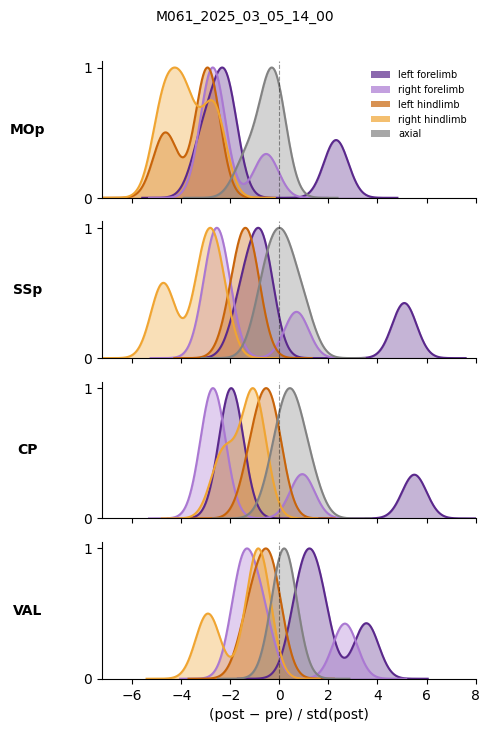

M061_2025_03_06_14_00 | MOp | left forelimb: n=4  mean=-2.71
M061_2025_03_06_14_00 | MOp | right forelimb: n=4  mean=-6.48
M061_2025_03_06_14_00 | MOp | left hindlimb: n=3  mean=-2.75
M061_2025_03_06_14_00 | MOp | right hindlimb: n=3  mean=-3.83
M061_2025_03_06_14_00 | MOp | axial: n=5  mean=-1.03
M061_2025_03_06_14_00 | SSp | left forelimb: n=4  mean=-5.43
M061_2025_03_06_14_00 | SSp | right forelimb: n=4  mean=-5.08
M061_2025_03_06_14_00 | SSp | left hindlimb: n=3  mean=-0.92
M061_2025_03_06_14_00 | SSp | right hindlimb: n=3  mean=-2.48
M061_2025_03_06_14_00 | SSp | axial: n=5  mean=-1.62
M061_2025_03_06_14_00 | CP | left forelimb: n=4  mean=-0.30
M061_2025_03_06_14_00 | CP | right forelimb: n=4  mean=-0.97
M061_2025_03_06_14_00 | CP | left hindlimb: n=3  mean=-1.42
M061_2025_03_06_14_00 | CP | right hindlimb: n=3  mean=-0.21
M061_2025_03_06_14_00 | CP | axial: n=5  mean=-0.73
M061_2025_03_06_14_00 | VAL | left forelimb: n=4  mean=0.59
M061_2025_03_06_14_00 | VAL | right forelimb: n=

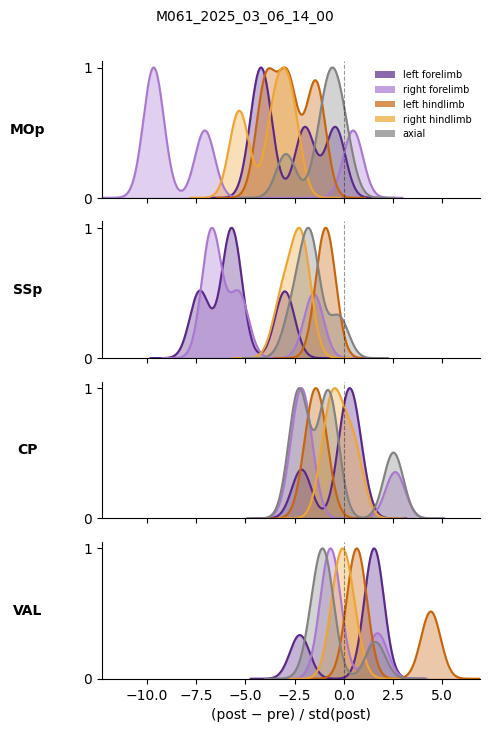

M063_2025_03_13_14_00 | MOp | left forelimb: n=4  mean=-0.14
M063_2025_03_13_14_00 | MOp | right forelimb: n=4  mean=-2.08
M063_2025_03_13_14_00 | MOp | left hindlimb: n=3  mean=-0.42
M063_2025_03_13_14_00 | MOp | right hindlimb: n=3  mean=-0.50
M063_2025_03_13_14_00 | MOp | axial: n=5  mean=-0.31
M063_2025_03_13_14_00 | SSp | left forelimb: n=4  mean=-0.52
M063_2025_03_13_14_00 | SSp | right forelimb: n=4  mean=-4.10
M063_2025_03_13_14_00 | SSp | left hindlimb: n=3  mean=-2.15
M063_2025_03_13_14_00 | SSp | right hindlimb: n=3  mean=-2.84
M063_2025_03_13_14_00 | SSp | axial: n=5  mean=-0.67
M063_2025_03_13_14_00 | CP | left forelimb: n=4  mean=1.32
M063_2025_03_13_14_00 | CP | right forelimb: n=4  mean=-0.54
M063_2025_03_13_14_00 | CP | left hindlimb: n=3  mean=-0.82
M063_2025_03_13_14_00 | CP | right hindlimb: n=3  mean=-0.20
M063_2025_03_13_14_00 | CP | axial: n=5  mean=-0.57
M063_2025_03_13_14_00 | VAL | left forelimb: n=4  mean=-1.06
M063_2025_03_13_14_00 | VAL | right forelimb: n=

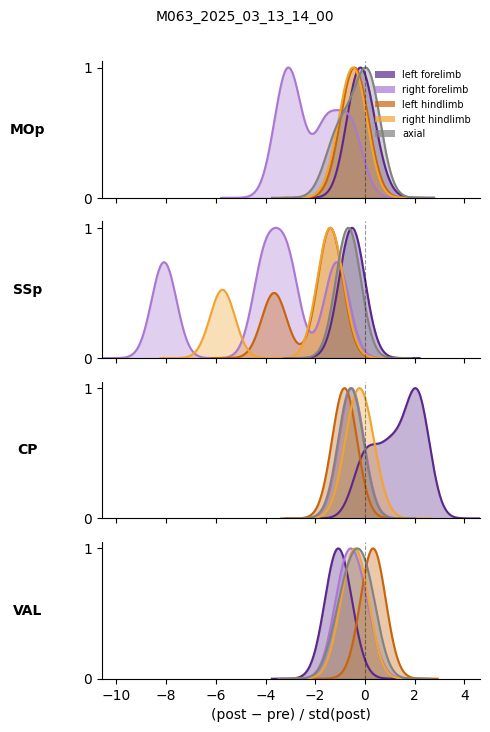

M062_2025_03_20_14_00 | MOp | left forelimb: n=4  mean=5.04
M062_2025_03_20_14_00 | MOp | right forelimb: n=4  mean=-2.96
M062_2025_03_20_14_00 | MOp | left hindlimb: n=3  mean=-2.93
M062_2025_03_20_14_00 | MOp | right hindlimb: n=3  mean=-2.52
M062_2025_03_20_14_00 | MOp | axial: n=5  mean=-3.20
M062_2025_03_20_14_00 | SSp | left forelimb: n=4  mean=0.54
M062_2025_03_20_14_00 | SSp | right forelimb: n=4  mean=-5.70
M062_2025_03_20_14_00 | SSp | left hindlimb: n=3  mean=-3.70
M062_2025_03_20_14_00 | SSp | right hindlimb: n=3  mean=-4.80
M062_2025_03_20_14_00 | SSp | axial: n=5  mean=-5.33
M062_2025_03_20_14_00 | CP | left forelimb: n=4  mean=4.84
M062_2025_03_20_14_00 | CP | right forelimb: n=4  mean=0.79
M062_2025_03_20_14_00 | CP | left hindlimb: n=3  mean=-0.35
M062_2025_03_20_14_00 | CP | right hindlimb: n=3  mean=-0.05
M062_2025_03_20_14_00 | CP | axial: n=5  mean=-0.02


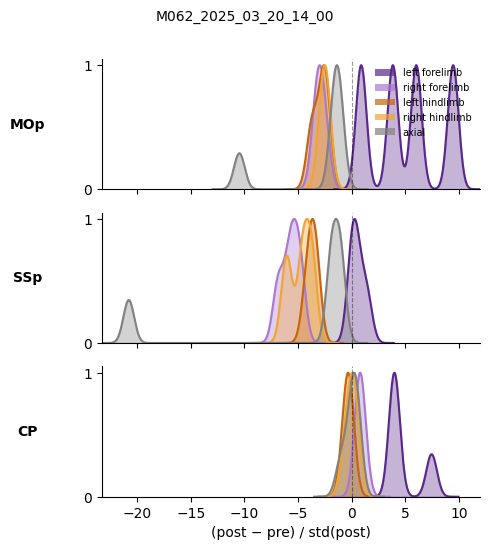

M062_2025_03_21_14_00 | MOp | left forelimb: n=4  mean=-2.21
M062_2025_03_21_14_00 | MOp | right forelimb: n=4  mean=-3.86
M062_2025_03_21_14_00 | MOp | left hindlimb: n=3  mean=-3.31
M062_2025_03_21_14_00 | MOp | right hindlimb: n=3  mean=-3.05
M062_2025_03_21_14_00 | MOp | axial: n=5  mean=-2.38
M062_2025_03_21_14_00 | SSp | left forelimb: n=4  mean=-2.69
M062_2025_03_21_14_00 | SSp | right forelimb: n=4  mean=-8.73
M062_2025_03_21_14_00 | SSp | left hindlimb: n=3  mean=-5.14
M062_2025_03_21_14_00 | SSp | right hindlimb: n=3  mean=-3.71
M062_2025_03_21_14_00 | SSp | axial: n=5  mean=-1.55
M062_2025_03_21_14_00 | CP | left forelimb: n=4  mean=2.41
M062_2025_03_21_14_00 | CP | right forelimb: n=4  mean=-0.44
M062_2025_03_21_14_00 | CP | left hindlimb: n=3  mean=-0.30
M062_2025_03_21_14_00 | CP | right hindlimb: n=3  mean=-0.23
M062_2025_03_21_14_00 | CP | axial: n=5  mean=-0.35


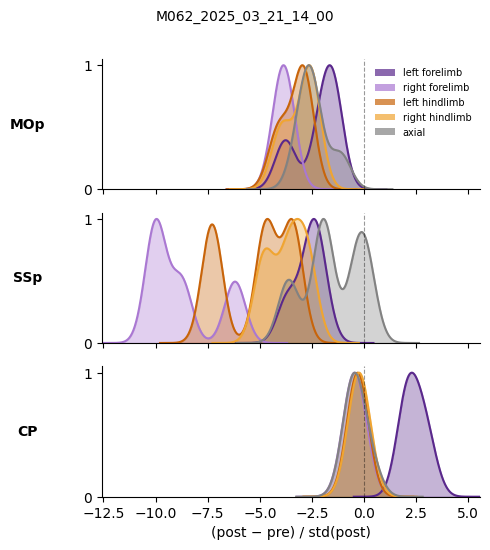

M078_2025_08_06_15_00 | MOp | left forelimb: n=4  mean=-2.08
M078_2025_08_06_15_00 | MOp | right forelimb: n=4  mean=-1.42
M078_2025_08_06_15_00 | MOp | left hindlimb: n=3  mean=-1.21
M078_2025_08_06_15_00 | MOp | right hindlimb: n=3  mean=-1.82
M078_2025_08_06_15_00 | MOp | axial: n=5  mean=0.22
M078_2025_08_06_15_00 | SSp | left forelimb: n=4  mean=-3.42
M078_2025_08_06_15_00 | SSp | right forelimb: n=4  mean=-1.74
M078_2025_08_06_15_00 | SSp | left hindlimb: n=3  mean=-3.77
M078_2025_08_06_15_00 | SSp | right hindlimb: n=3  mean=-3.09
M078_2025_08_06_15_00 | SSp | axial: n=5  mean=-0.48
M078_2025_08_06_15_00 | CP | left forelimb: n=4  mean=-0.68
M078_2025_08_06_15_00 | CP | right forelimb: n=4  mean=-2.60
M078_2025_08_06_15_00 | CP | left hindlimb: n=3  mean=-0.44
M078_2025_08_06_15_00 | CP | right hindlimb: n=3  mean=-1.21
M078_2025_08_06_15_00 | CP | axial: n=5  mean=-0.29
M078_2025_08_06_15_00 | VAL | left forelimb: n=4  mean=0.60
M078_2025_08_06_15_00 | VAL | right forelimb: n=4

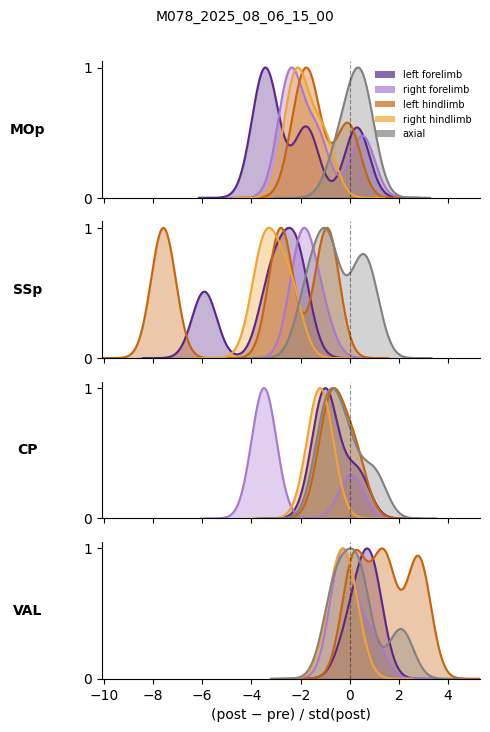

In [54]:

from scipy.stats import gaussian_kde

KDE_SESSIONS = sessions
KDE_AREAS    = ['MOp', 'SSp', 'CP', 'VAL']
KDE_BW       = 0.5   # absolute bandwidth in z-score units

GROUPS = {
    'left forelimb':  ['left_shoulder', 'left_elbow', 'left_wrist', 'left_paw'],
    'right forelimb': ['right_shoulder', 'right_elbow', 'right_wrist', 'right_paw'],
    'left hindlimb':  ['left_knee', 'left_ankle', 'left_foot'],
    'right hindlimb': ['right_knee', 'right_ankle', 'right_foot'],
    'axial':          ['shoulder_center', 'hip_center', 'tail_base', 'tail_middle', 'tail_tip'],
}
GROUP_COLORS = {
    'left forelimb':  np.array([90,  40, 140]) / 255,
    'right forelimb': np.array([170, 120, 210]) / 255,
    'left hindlimb':  np.array([200, 100,  10]) / 255,
    'right hindlimb': np.array([240, 165,  50]) / 255,
    'axial':          np.array([130, 130, 130]) / 255,
}

def bscore(pre_folds, post_folds):
    return (post_folds.mean() - pre_folds.mean()) / post_folds.std()

def plot_kde_norm(ax, vals, color, bw):
    vals = np.array(vals, dtype=float)
    std = vals.std(ddof=1) if len(vals) > 1 else 1.0
    factor = bw / std if std > 0 else 1.0
    kde = gaussian_kde(vals, bw_method=factor)
    xs = np.linspace(vals.min() - 5 * bw, vals.max() + 5 * bw, 400)
    ys = kde(xs)
    ys /= ys.max()
    ax.plot(xs, ys, color=color, lw=1.5)
    ax.fill_between(xs, ys, alpha=0.35, color=color)
    return xs[0], xs[-1]

for sess in KDE_SESSIONS:
    if sess not in results:
        continue

    sess_areas = [a for a in KDE_AREAS if a in results[sess]]
    fig, axes = plt.subplots(len(sess_areas), 1,
                             figsize=(5, 1.8 * len(sess_areas)),
                             sharex=True)
    if len(sess_areas) == 1:
        axes = [axes]

    xmins, xmaxs = [], []
    for ax, area in zip(axes, sess_areas):
        d = results[sess][area]

        for grp_name, kp_list in GROUPS.items():
            vals = [bscore(d[kp]['pre'], d[kp]['post'])
                    for kp in kp_list if kp in d and 'pre' in d[kp] and 'post' in d[kp]]
            if len(vals) < 2:
                continue
            x0, x1 = plot_kde_norm(ax, vals, GROUP_COLORS[grp_name], KDE_BW)
            xmins.append(x0); xmaxs.append(x1)
            print(f'{sess} | {area} | {grp_name}: n={len(vals)}  mean={np.mean(vals):.2f}')

        ax.axvline(0, color='k', lw=0.8, ls='--', alpha=0.4)
        ax.set_ylim(0, 1.05)
        ax.set_yticks([0, 1])
        ax.set_ylabel(area, fontsize=10, fontweight='bold', rotation=0,
                      labelpad=40, va='center')
        sns.despine(ax=ax)

    if xmins:
        for ax in axes:
            ax.set_xlim(min(xmins), max(xmaxs))

    from matplotlib.patches import Patch
    axes[0].legend(
        handles=[Patch(facecolor=GROUP_COLORS[g], alpha=0.7, label=g) for g in GROUPS],
        frameon=False, fontsize=7, loc='upper right'
    )
    axes[-1].set_xlabel('(post − pre) / std(post)', fontsize=10)
    fig.suptitle(sess, fontsize=10, y=1.01)
    fig.tight_layout()
    plt.show()


MOp | left forelimb: n_sess=7
MOp | right forelimb: n_sess=7
MOp | left hindlimb: n_sess=7
MOp | right hindlimb: n_sess=7
MOp | axial: n_sess=7
SSp | left forelimb: n_sess=7
SSp | right forelimb: n_sess=7
SSp | left hindlimb: n_sess=7
SSp | right hindlimb: n_sess=7
SSp | axial: n_sess=7
CP | left forelimb: n_sess=7
CP | right forelimb: n_sess=7
CP | left hindlimb: n_sess=7
CP | right hindlimb: n_sess=7
CP | axial: n_sess=7
VAL | left forelimb: n_sess=5
VAL | right forelimb: n_sess=5
VAL | left hindlimb: n_sess=5
VAL | right hindlimb: n_sess=5
VAL | axial: n_sess=5


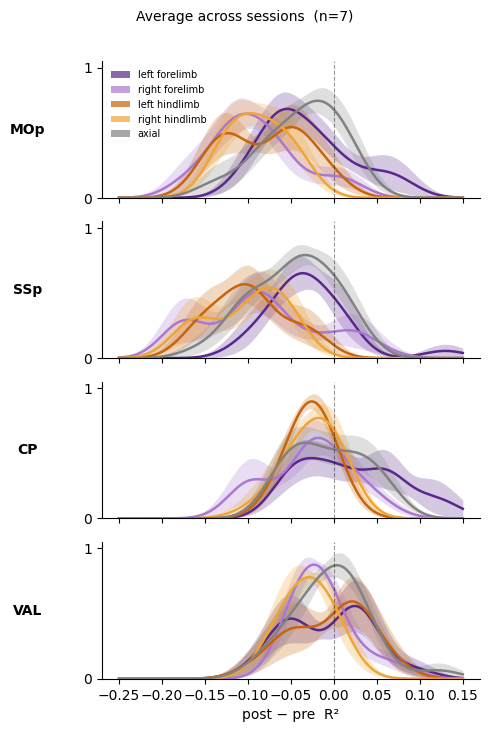

In [71]:

from scipy.stats import gaussian_kde

AVG_SESSIONS = sessions
AVG_AREAS    = ['MOp', 'SSp', 'CP', 'VAL']
AVG_BW       = 0.025
AVG_XMIN     = -0.25
AVG_XMAX     =  0.15

GROUPS = {
    'left forelimb':  ['left_shoulder', 'left_elbow', 'left_wrist', 'left_paw'],
    'right forelimb': ['right_shoulder', 'right_elbow', 'right_wrist', 'right_paw'],
    'left hindlimb':  ['left_knee', 'left_ankle', 'left_foot'],
    'right hindlimb': ['right_knee', 'right_ankle', 'right_foot'],
    'axial':          ['shoulder_center', 'hip_center', 'tail_base', 'tail_middle', 'tail_tip'],
}
GROUP_COLORS = {
    'left forelimb':  np.array([90,  40, 140]) / 255,
    'right forelimb': np.array([170, 120, 210]) / 255,
    'left hindlimb':  np.array([200, 100,  10]) / 255,
    'right hindlimb': np.array([240, 165,  50]) / 255,
    'axial':          np.array([130, 130, 130]) / 255,
}

def bscore(pre_folds, post_folds):
    return (post_folds.mean() - pre_folds.mean()) #/ post_folds.std()

xs = np.linspace(AVG_XMIN, AVG_XMAX, 400)

fig, axes = plt.subplots(len(AVG_AREAS), 1,
                         figsize=(5, 1.8 * len(AVG_AREAS)),
                         sharex=True)

for ax, area in zip(axes, AVG_AREAS):
    for grp_name, kp_list in GROUPS.items():
        col = GROUP_COLORS[grp_name]
        curves = []   # one normalized KDE curve per session

        for sess in AVG_SESSIONS:
            if sess not in results or area not in results[sess]:
                continue
            d = results[sess][area]
            vals = [bscore(d[kp]['pre'], d[kp]['post'])
                    for kp in kp_list if kp in d and 'pre' in d[kp] and 'post' in d[kp]]
            if len(vals) < 2:
                continue

            std = np.std(vals, ddof=1)
            factor = AVG_BW / std if std > 0 else 1.0
            kde = gaussian_kde(vals, bw_method=factor)
            y = kde(xs)
            curves.append(y / y.max())   # normalize each to peak = 1

        if len(curves) < 2:
            continue

        curves  = np.array(curves)          # (n_sessions, n_x)
        mean_c  = curves.mean(axis=0)
        sem_c   = curves.std(axis=0) / np.sqrt(len(curves))

        ax.plot(xs, mean_c, color=col, lw=1.8)
        ax.fill_between(xs, mean_c - sem_c, mean_c + sem_c,
                        color=col, alpha=0.25, linewidth=0)

        print(f'{area} | {grp_name}: n_sess={len(curves)}')

    ax.axvline(0, color='k', lw=0.8, ls='--', alpha=0.4)
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0, 1])
    ax.set_ylabel(area, fontsize=10, fontweight='bold', rotation=0,
                  labelpad=40, va='center')
    sns.despine(ax=ax)

from matplotlib.patches import Patch
axes[0].legend(
    handles=[Patch(facecolor=GROUP_COLORS[g], alpha=0.7, label=g) for g in GROUPS],
    frameon=False, fontsize=7, loc='upper left'
)
axes[-1].set_xlabel('post − pre  R²', fontsize=10)
fig.suptitle(f'Average across sessions  (n={len(AVG_SESSIONS)})', fontsize=10, y=1.01)
fig.tight_layout()
plt.show()


MOp | left forelimb: mean=-0.029 ± 0.040  (n=7)
MOp | right forelimb: mean=-0.092 ± 0.026  (n=7)
MOp | left hindlimb: mean=-0.085 ± 0.041  (n=7)
MOp | right hindlimb: mean=-0.089 ± 0.027  (n=7)
MOp | axial: mean=-0.035 ± 0.031  (n=7)
SSp | left forelimb: mean=-0.030 ± 0.033  (n=7)
SSp | right forelimb: mean=-0.085 ± 0.063  (n=7)
SSp | left hindlimb: mean=-0.099 ± 0.040  (n=7)
SSp | right hindlimb: mean=-0.101 ± 0.042  (n=7)
SSp | axial: mean=-0.045 ± 0.028  (n=7)
CP | left forelimb: mean=0.022 ± 0.050  (n=7)
CP | right forelimb: mean=-0.025 ± 0.029  (n=7)
CP | left hindlimb: mean=-0.027 ± 0.013  (n=7)
CP | right hindlimb: mean=-0.025 ± 0.024  (n=7)
CP | axial: mean=-0.006 ± 0.031  (n=7)
VAL | left forelimb: mean=-0.008 ± 0.040  (n=5)
VAL | right forelimb: mean=-0.013 ± 0.015  (n=5)
VAL | left hindlimb: mean=-0.004 ± 0.040  (n=5)
VAL | right hindlimb: mean=-0.030 ± 0.021  (n=5)
VAL | axial: mean=-0.001 ± 0.023  (n=5)


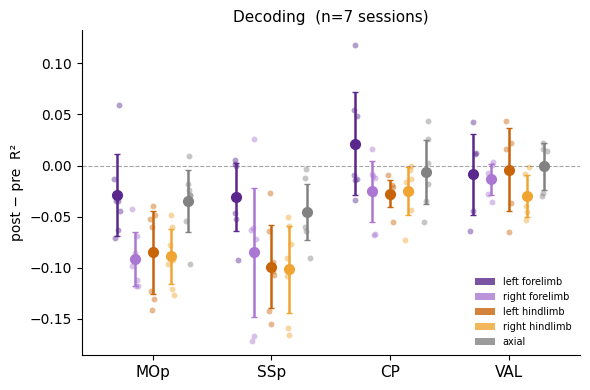

In [70]:

EB_SESSIONS = sessions
EB_AREAS    = ['MOp', 'SSp', 'CP', 'VAL']

GROUPS = {
    'left forelimb':  ['left_shoulder', 'left_elbow', 'left_wrist', 'left_paw'],
    'right forelimb': ['right_shoulder', 'right_elbow', 'right_wrist', 'right_paw'],
    'left hindlimb':  ['left_knee', 'left_ankle', 'left_foot'],
    'right hindlimb': ['right_knee', 'right_ankle', 'right_foot'],
    'axial':          ['shoulder_center', 'hip_center', 'tail_base', 'tail_middle', 'tail_tip'],
}
GROUP_COLORS = {
    'left forelimb':  np.array([90,  40, 140]) / 255,
    'right forelimb': np.array([170, 120, 210]) / 255,
    'left hindlimb':  np.array([200, 100,  10]) / 255,
    'right hindlimb': np.array([240, 165,  50]) / 255,
    'axial':          np.array([130, 130, 130]) / 255,
}

def bscore(pre_folds, post_folds):
    return post_folds.mean() - pre_folds.mean()

n_groups  = len(GROUPS)
grp_names = list(GROUPS.keys())
offsets   = np.linspace(-0.3, 0.3, n_groups)   # x-offsets within each area
DOT_SIZE  = 18
JITTER    = 0.025

rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(6, 4))

for ai, area in enumerate(EB_AREAS):
    for gi, (grp_name, kp_list) in enumerate(GROUPS.items()):
        col = GROUP_COLORS[grp_name]
        xpos = ai + offsets[gi]

        # one value per session = mean across keypoints in group
        sess_vals = []
        for sess in EB_SESSIONS:
            if sess not in results or area not in results[sess]:
                continue
            d = results[sess][area]
            vals = [bscore(d[kp]['pre'], d[kp]['post'])
                    for kp in kp_list if kp in d and 'pre' in d[kp] and 'post' in d[kp]]
            if vals:
                sess_vals.append(np.mean(vals))

        if not sess_vals:
            continue

        sess_vals = np.array(sess_vals)
        m  = sess_vals.mean()
        se = sess_vals.std() #/ np.sqrt(len(sess_vals))

        # individual session dots
        jx = rng.uniform(-JITTER, JITTER, size=len(sess_vals))
        ax.scatter(xpos + jx, sess_vals, color=col, s=DOT_SIZE,
                   alpha=0.45, linewidths=0, zorder=2)

        # mean ± SEM errorbar
        ax.errorbar(xpos, m, yerr=se, fmt='o', color=col,
                    markersize=7, capsize=2.5, lw=1.8, zorder=4)

        print(f'{area} | {grp_name}: mean={m:.3f} ± {se:.3f}  (n={len(sess_vals)})')

ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.35)
ax.set_xticks(range(len(EB_AREAS)))
ax.set_xticklabels(EB_AREAS, fontsize=11)
ax.set_ylabel('post − pre  R²', fontsize=10)
ax.set_title(f'Decoding  (n={len(EB_SESSIONS)} sessions)', fontsize=11)
ax.set_xlim(-0.6, len(EB_AREAS) - 0.4)

from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(facecolor=GROUP_COLORS[g], alpha=0.8, label=g) for g in grp_names],
    frameon=False, fontsize=7, loc='lower right', ncol=1
)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


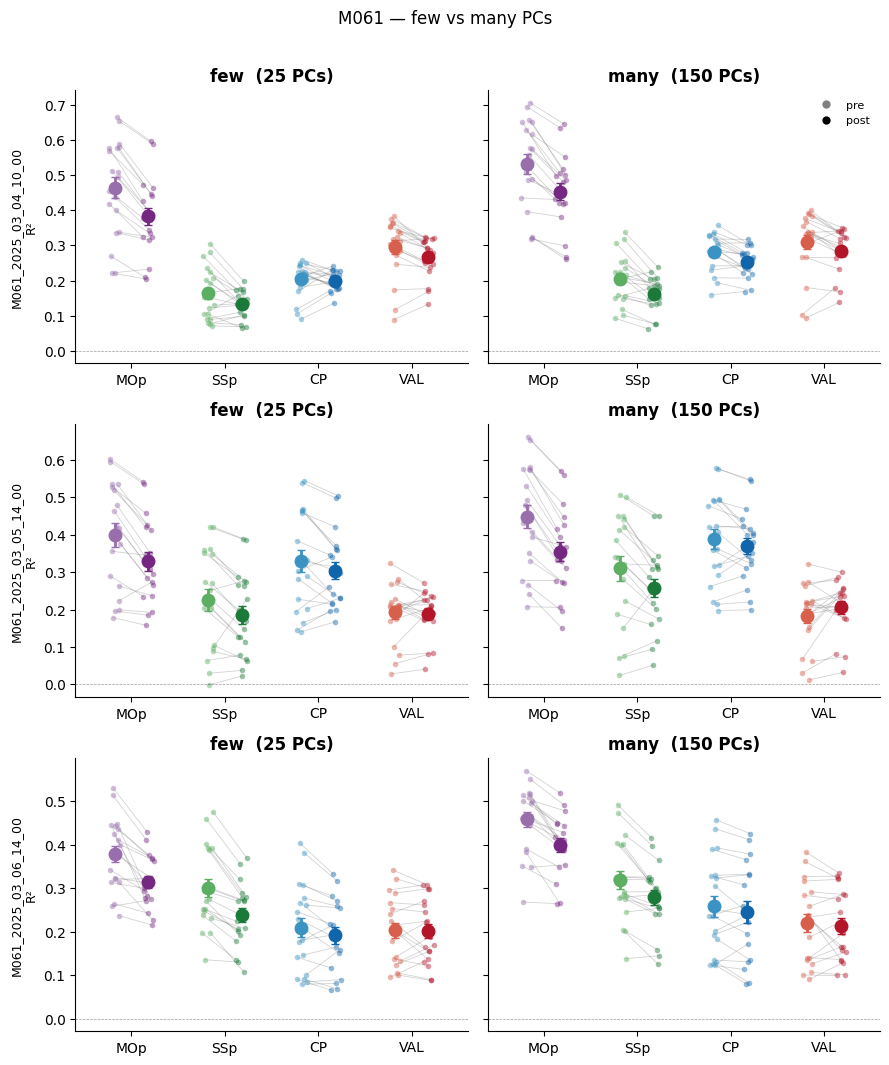

In [75]:

PC_SESSIONS = [
    'M061_2025_03_04_10_00',
    'M061_2025_03_05_14_00',
    'M061_2025_03_06_14_00',
]
PC_AREAS    = ['MOp', 'SSp', 'CP', 'VAL']

# few = default pc_dict values, many = 150 (or max available for SSp)
FEW_PCS  = {'MOp': 25,  'SSp': 15,  'CP': 30,  'VAL': 50}
MANY_PCS = {'MOp': 150, 'SSp': None, 'CP': 150, 'VAL': 150}  # None = auto-detect max

AREA_COLORS = {
    area: {'post': getattr(colors, area), 'pre': getattr(colors, f'{area}_light')}
    for area in PC_AREAS
}
OFFSET  = 0.18
JITTER  = 0.06
KP_ALPHA = 0.35

def load_pc_results(sessions, areas, few_pcs, many_pcs, results_dir):
    out = {}
    for sess in sessions:
        out[sess] = {}
        for area in areas:
            pattern = f'kin_dec_pre_post_{area}_{sess}_npcs*.pkl'
            files = sorted(results_dir.glob(pattern))
            if not files:
                continue
            variants = {}
            for f in files:
                npcs = int(f.stem.split('npcs')[-1])
                with open(f, 'rb') as fh:
                    variants[npcs] = pickle.load(fh)

            few_n  = few_pcs[area]
            many_n = many_pcs[area] if many_pcs[area] is not None else max(variants)

            if few_n in variants and many_n in variants:
                out[sess][area] = {'few': variants[few_n], 'many': variants[many_n],
                                   'few_n': few_n, 'many_n': many_n}
    return out

pc_results = load_pc_results(PC_SESSIONS, PC_AREAS, FEW_PCS, MANY_PCS, RESULTS_DIR)

rng = np.random.default_rng(0)

fig, axes = plt.subplots(len(PC_SESSIONS), 2,
                         figsize=(9, 3.5 * len(PC_SESSIONS)),
                         sharey='row')

for ri, sess in enumerate(PC_SESSIONS):
    for ci, cond in enumerate(['few', 'many']):
        ax = axes[ri, ci]
        sess_areas = [a for a in PC_AREAS if a in pc_results[sess]
                      and cond in pc_results[sess][a]]
        if not sess_areas:
            continue

        kp_sets = [
            set(k for k in pc_results[sess][a][cond]
                if k != '_meta' and 'pre' in pc_results[sess][a][cond][k]
                and 'post' in pc_results[sess][a][cond][k])
            for a in sess_areas
        ]
        common_kps = sorted(set.intersection(*kp_sets))

        for ai, area in enumerate(sess_areas):
            d = pc_results[sess][area][cond]
            x_pre, x_post = ai - OFFSET, ai + OFFSET
            col_pre  = AREA_COLORS[area]['pre']
            col_post = AREA_COLORS[area]['post']

            pre_vals  = np.array([d[kp]['pre'].mean()  for kp in common_kps])
            post_vals = np.array([d[kp]['post'].mean() for kp in common_kps])

            for v_pre, v_post in zip(pre_vals, post_vals):
                jx = rng.uniform(-JITTER, JITTER)
                ax.plot([x_pre + jx, x_post + jx], [v_pre, v_post],
                        color='grey', lw=0.6, alpha=KP_ALPHA, zorder=1)
                ax.scatter(x_pre  + jx, v_pre,  color=col_pre,  s=16,
                           alpha=KP_ALPHA + 0.1, linewidths=0, zorder=2)
                ax.scatter(x_post + jx, v_post, color=col_post, s=16,
                           alpha=KP_ALPHA + 0.1, linewidths=0, zorder=2)

            for x, vals, col in [(x_pre, pre_vals, col_pre),
                                  (x_post, post_vals, col_post)]:
                m, se = vals.mean(), vals.std() / np.sqrt(len(vals))
                ax.errorbar(x, m, yerr=se, fmt='o', color=col,
                            markersize=9, capsize=3, lw=2, zorder=5)

        # fix: few_n/many_n are at the area level, not inside the data dict
        n_pcs = pc_results[sess][sess_areas[0]][f'{cond}_n']
        ax.set_xticks(range(len(sess_areas)))
        ax.set_xticklabels(sess_areas)
        ax.set_xlim(-0.6, len(sess_areas) - 0.4)
        ax.axhline(0, color='k', lw=0.5, ls='--', alpha=0.4)
        ax.set_title(f'{cond}  ({n_pcs} PCs)', fontweight='bold')
        if ci == 0:
            ax.set_ylabel(f'{sess}\nR²', fontsize=9)
        sns.despine(ax=ax)

from matplotlib.lines import Line2D
axes[0, 1].legend(
    handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
                    markersize=7, label='pre'),
             Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
                    markersize=7, label='post')],
    frameon=False, fontsize=8, loc='upper right'
)
fig.suptitle('M061 — few vs many PCs', fontsize=12, y=1.01)
fig.tight_layout()
plt.show()
